---
# Henon 2D,  Invariant plot
---

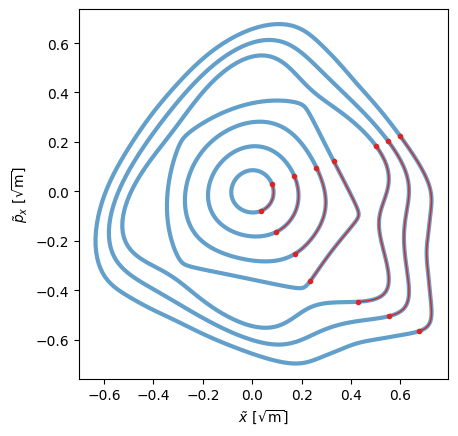

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import nafflib
import pytori as pt
import pytori.plotting as ptplt

# ========================
# Henon parameters
num_turns   = int(2e4)
Q0          = 0.2071
# ========================


# Non-resonant initial conditions
x_start    = np.array([0.08, 0.17,0.26, 0.33, 0.50, 0.55, 0.6])
px_start   = 0.37 * x_start

tori    = []
for x0, px0 in zip(x_start, px_start):
    # Iterating Henon map
    x, px   = nafflib.henon_map(x0, px0, Q0, num_turns)

    # Extracting harmonics:
    #============================================================================
    n_harm  = 100
    w_order = 4
    Ax,Qx   = nafflib.harmonics(x,px,num_harmonics = n_harm,window_order=w_order)
    #============================================================================

    # Indexing harmonics
    #============================================================================
    max_n       = 90 #(high numbers needed in 2D..)
    max_alias   = 50
    warning_tol = np.inf #Disable warnings
    Qvec    = [Qx[0]]
    nx      = nafflib.linear_combinations(Qx,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)
    #============================================================================

    # Building torus (2D-torus)
    #============================================================================
    _torus = pt.Torus.from_naff(n=[nx],A=[Ax])
    tori.append(_torus)
    #============================================================================


# Plotting
#--------------------------------------------------


plt.figure()
for torus in tori:
    # Full loop around 0-2pi
    ptplt.xloop(torus,num_points=200,edgecolor='C0',alpha=0.7,lw=3)

    # Free hand plot of the torus
    Tx = np.linspace(0,2*np.pi/4,200) # Theta_x values
    plt.plot(torus.X(Tx), torus.PX(Tx),'-',color='C3',lw=1)
    plt.plot(torus.X(Tx[0]), torus.PX(Tx[0]),'o',color='C3',ms=3)
    plt.plot(torus.X(Tx[-1]), torus.PX(Tx[-1]),'o',color='C3',ms=3)




plt.axis('equal')
plt.gca().set_box_aspect(1) 
plt.xlabel(r'$\tilde x\ [\sqrt{\mathrm{m}}]$');
plt.ylabel(r'$\tilde p_x\ [\sqrt{\mathrm{m}}]$');




# # Resonant initial conditions
# x_points    = np.array([0.46])
# px_points   = 0.37 * x_points
# res_order = 5


---
# Inspecting Torus and Fourier Series
---

In [4]:
torus

╭─────────────────────────────────────────────── Torus (FourierSeries) ────────────────────────────────────────────────╮
│                                                                                                                      │
│  ╭────────────────────── x ──────────────────────╮                                                                   │
│  │                                               │                                                                   │
│  │   Index   Value                   Norm        │                                                                   │
│  │   ( 0)    4.141e-01 + 8.649e-02j  4.231e-01   │                                                                   │
│  │   ( 1)   -3.933e-02 - 8.174e-02j  9.071e-02   │                                                                   │
│  │   (-1)   -2.296e-02 - 3.397e-02j  4.100e-02   │                                                                   │
│  │   ( 2)   -8.725e-03 - 1.216e-02j  1.496e-02   │                                                                   │
│  │   (-2)   -6.069e-03 - 6.696e-04j  6.106e-03   │                                                                   │
│  │   ( 3)    3.567e-03 + 1.088e-03j  3.729e-03   │                                                                   │
│  │   (-3)   -3.576e-04 - 1.017e-03j  1.078e-03   │                                                                   │
│  │   ( 4)    8.271e-05 + 9.622e-04j  9.658e-04   │                                                                   │
│  │   (-4)   -3.488e-04 - 7.808e-05j  3.574e-04   │                                                                   │
│  │   ( 5)    2.396e-04 + 1.097e-04j  2.636e-04   │                                                                   │
│  │   ...    ...                      ...         │                                                                   │
│  │                                               │                                                                   │
│  ╰────────────────── terms=100 ──────────────────╯                                                                   │
│                                                                                                                      │
╰────── dim=1, β₀=(1, 1, 1), (Ix)=(0.00348), max_order=None, max_terms=100, numerical_tol=None, backend='numpy' ───────╯

In [2]:
# Display parameters can be changed globally
from pytori.display import DISPLAY_FMT,HAS_RICH
DISPLAY_FMT.fmt     = ".3e"   
DISPLAY_FMT.n_terms = 10

# Choosing example torus and displaying
torus = tori[1]
display(torus)

# We can also inspect a specific projection
display(torus.x)

╭─────────────────────────────────────────────── Torus (FourierSeries) ────────────────────────────────────────────────╮
│                                                                                                                      │
│  ╭────────────────────── x ──────────────────────╮                                                                   │
│  │                                               │                                                                   │
│  │   Index   Value                   Norm        │                                                                   │
│  │   ( 1)   -1.634e-01 - 8.071e-02j  1.823e-01   │                                                                   │
│  │   ( 0)    1.103e-02 + 8.397e-03j  1.386e-02   │                                                                   │
│  │   ( 2)    1.920e-05 + 6.916e-03j  6.917e-03   │                                                                   │
│  │   (-2)    4.291e-03 + 1.198e-03j  4.455e-03   │                                                                   │
│  │   (-1)    1.325e-04 + 6.924e-04j  7.049e-04   │                                                                   │
│  │   (-3)    3.909e-04 + 4.335e-04j  5.837e-04   │                                                                   │
│  │   (-4)    1.422e-04 + 3.608e-04j  3.878e-04   │                                                                   │
│  │   ( 3)   -2.840e-04 - 1.422e-04j  3.177e-04   │                                                                   │
│  │   ( 4)   -3.202e-05 - 2.409e-05j  4.007e-05   │                                                                   │
│  │   ( 5)   -5.788e-06 - 3.117e-05j  3.171e-05   │                                                                   │
│  │   ...    ...                      ...         │                                                                   │
│  │                                               │                                                                   │
│  ╰────────────────── terms=40 ───────────────────╯                                                                   │
│                                                                                                                      │
╰─────── dim=1, β₀=(1, 1, 1), (Ix)=(0.0166), max_order=None, max_terms=100, numerical_tol=None, backend='numpy' ───────╯

╭───────────────────────────────────────── FourierSeries ──────────────────────────────────────────╮
│                                                                                                  │
│   Index   Value                   Norm                                                           │
│   ( 1)   -1.634e-01 - 8.071e-02j  1.823e-01                                                      │
│   ( 0)    1.103e-02 + 8.397e-03j  1.386e-02                                                      │
│   ( 2)    1.920e-05 + 6.916e-03j  6.917e-03                                                      │
│   (-2)    4.291e-03 + 1.198e-03j  4.455e-03                                                      │
│   (-1)    1.325e-04 + 6.924e-04j  7.049e-04                                                      │
│   (-3)    3.909e-04 + 4.335e-04j  5.837e-04                                                      │
│   (-4)    1.422e-04 + 3.608e-04j  3.878e-04                                                      │
│   ( 3)   -2.840e-04 - 1.422e-04j  3.177e-04                                                      │
│   ( 4)   -3.202e-05 - 2.409e-05j  4.007e-05                                                      │
│   ( 5)   -5.788e-06 - 3.117e-05j  3.171e-05                                                      │
│   ...    ...                      ...                                                            │
│                                                                                                  │
╰────── dim=1, terms=40, max_order=None, max_terms=100, numerical_tol=None, backend='numpy' ───────╯

---
# Resonance Islands
---

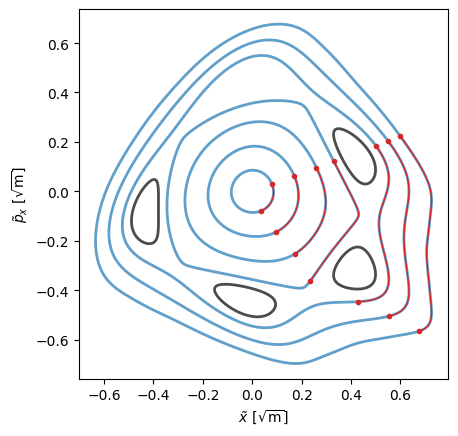

In [3]:
# Resonant initial conditions
x_start    = np.array([0.46])
px_starts  = 0.37 * x_start
res_order = 5

res_tori    = []
for x0, px0 in zip(x_start, px_start):
    # Iterating Henon map
    x, px   = nafflib.henon_map(x0, px0, Q0, num_turns)

    # Oversampling and recentering around the resonance (helps the numerical stability)
    #============================================================================
    x   = x[::res_order]    
    px  = px[::res_order]
    x_c,px_c = np.mean(x),np.mean(px)
    x   -= x_c
    px  -= px_c
    #============================================================================

    # Extracting harmonics:
    #============================================================================
    n_harm  = 100
    w_order = 4
    Ax,Qx   = nafflib.harmonics(x,px,num_harmonics = n_harm,window_order=w_order)
    #============================================================================

    # Indexing harmonics
    #============================================================================
    max_n       = 90 #(high numbers needed in 2D..)
    max_alias   = 50
    warning_tol = np.inf #Disable warnings
    Qvec    = [Qx[0]]
    nx      = nafflib.linear_combinations(Qx,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)
    #============================================================================

    # Building torus (2D-torus)
    #============================================================================
    _torus = pt.Torus.from_naff(n=[nx],A=[Ax])
    # Repositioning torus to original center
    _torus.x += x_c - 1j*px_c
    res_tori.append(_torus)
    #============================================================================


# Plotting
#--------------------------------------------------
plt.figure()
for torus in tori:
    # Full loop around 0-2pi
    ptplt.xloop(torus,num_points=200,edgecolor='C0',alpha=0.7,lw=2)

    # Free hand plot of the torus
    Tx = np.linspace(0,2*np.pi/4,200) # Theta_x values
    plt.plot(torus.X(Tx), torus.PX(Tx),'-',color='C3',lw=1)
    plt.plot(torus.X(Tx[0]), torus.PX(Tx[0]),'o',color='C3',ms=3)
    plt.plot(torus.X(Tx[-1]), torus.PX(Tx[-1]),'o',color='C3',ms=3)

for torus in res_tori:
    # Full loop around 0-2pi
    ptplt.xloop(torus,num_points=200,edgecolor='k',alpha=0.7,lw=2)

    # Transformed island:
    def HENON(_psi,Q0):
        _psi.x  = np.exp(1j*2*np.pi*Q0)*(_psi.x - 1j/4*(_psi.x.conj() + _psi.x)**2)
        return _psi

    # Showing the first few to make it explicit
    for _ in range(3):
        torus = HENON(torus,Q0)
        ptplt.xloop(torus,num_points=200,edgecolor='k',alpha=0.7,lw=2)




plt.axis('equal')
plt.gca().set_box_aspect(1) 
plt.xlabel(r'$\tilde x\ [\sqrt{\mathrm{m}}]$');
plt.ylabel(r'$\tilde p_x\ [\sqrt{\mathrm{m}}]$');





